<a href="https://colab.research.google.com/github/arunangshu19/PINN/blob/schrodinger/tise_angular_l3_m2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== Run 1/5 ===
Iter    0 PDE Loss: 1.240e+00
Iter  500 PDE Loss: 1.542e-05
Iter 1000 PDE Loss: 1.033e-03
Iter 1500 PDE Loss: 2.629e-04
Iter 2000 PDE Loss: 3.520e-07
Iter 2500 PDE Loss: 2.985e-07
Iter 3000 PDE Loss: 3.052e-07
Iter 3500 PDE Loss: 2.289e-07
Iter 4000 PDE Loss: 2.242e-07
Iter 4500 PDE Loss: 2.152e-07


/tmp/ipython-input-341444744.py:112: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(pred**2 * weights, theta_grid))



=== Run 2/5 ===
Iter    0 PDE Loss: 1.797e+00
Iter  500 PDE Loss: 1.985e-06
Iter 1000 PDE Loss: 4.119e-06
Iter 1500 PDE Loss: 7.926e-07
Iter 2000 PDE Loss: 3.512e-06
Iter 2500 PDE Loss: 6.203e-07
Iter 3000 PDE Loss: 3.576e-07
Iter 3500 PDE Loss: 3.143e-07
Iter 4000 PDE Loss: 2.952e-07
Iter 4500 PDE Loss: 2.731e-07


/usr/local/lib/python3.12/dist-packages/torch/optim/lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  loss = float(closure())



=== Run 3/5 ===
Iter    0 PDE Loss: 2.543e+00
Iter  500 PDE Loss: 2.252e-06
Iter 1000 PDE Loss: 1.411e-06
Iter 1500 PDE Loss: 1.325e-05
Iter 2000 PDE Loss: 4.272e-06
Iter 2500 PDE Loss: 1.370e-06
Iter 3000 PDE Loss: 4.560e-07
Iter 3500 PDE Loss: 4.003e-07
Iter 4000 PDE Loss: 3.411e-07
Iter 4500 PDE Loss: 3.304e-07

=== Run 4/5 ===
Iter    0 PDE Loss: 1.125e+00
Iter  500 PDE Loss: 5.668e-04
Iter 1000 PDE Loss: 4.247e-06
Iter 1500 PDE Loss: 6.481e-07
Iter 2000 PDE Loss: 3.488e-07
Iter 2500 PDE Loss: 2.646e-07
Iter 3000 PDE Loss: 2.242e-07
Iter 3500 PDE Loss: 1.830e-07
Iter 4000 PDE Loss: 1.892e-07
Iter 4500 PDE Loss: 1.874e-07

=== Run 5/5 ===
Iter    0 PDE Loss: 6.553e-01
Iter  500 PDE Loss: 1.729e-05
Iter 1000 PDE Loss: 7.273e-06
Iter 1500 PDE Loss: 9.295e-06
Iter 2000 PDE Loss: 6.696e-07
Iter 2500 PDE Loss: 4.691e-07
Iter 3000 PDE Loss: 3.727e-07
Iter 3500 PDE Loss: 2.821e-07
Iter 4000 PDE Loss: 2.557e-07
Iter 4500 PDE Loss: 2.514e-07


/tmp/ipython-input-341444744.py:124: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.sqrt(np.trapz(a**2 * w, theta_grid))
/tmp/ipython-input-341444744.py:120: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(a * b * w, theta_grid)


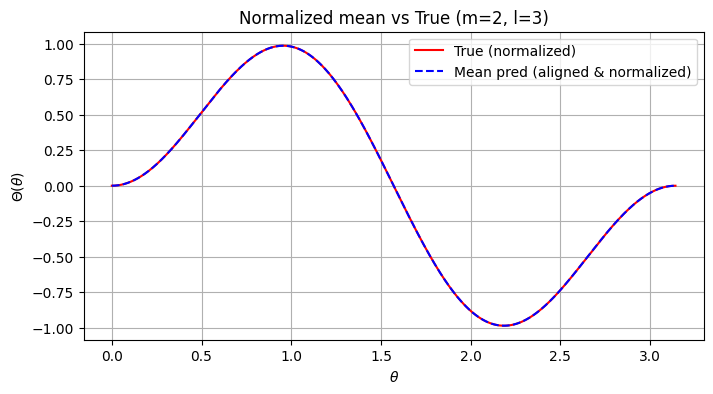

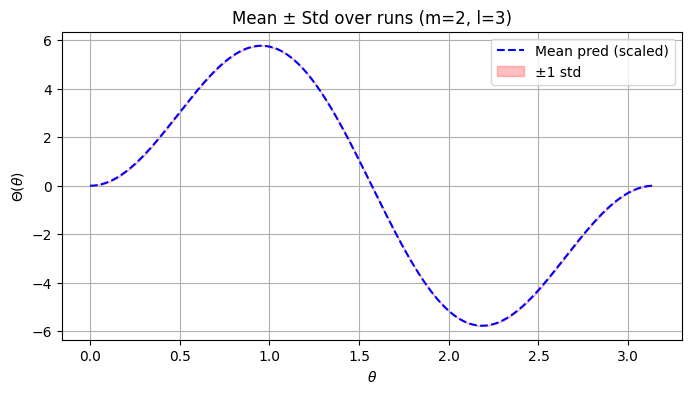

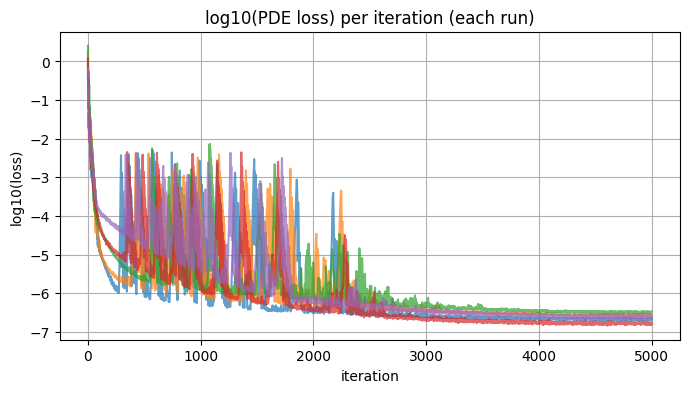

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
from scipy.special import lpmv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === USER PARAMETERS ===
l = 3
m = 2

n_points_pool = 20000
batch_size = 2048
n_iter = 5000
lr = 1e-4
clip_norm = 5.0
n_runs = 5   # change to how many independent runs you want
# ========================

# SIREN-style Network with sine first layer activation
class SIREN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.linears = nn.ModuleList()
        for i in range(len(layers)-1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        self.act_first = torch.sin
        self.act_hidden = torch.tanh

        # Initialize weights
        with torch.no_grad():
            self.linears[0].weight.uniform_(-1, 1)
            for lin in self.linears[1:]:
                nn.init.xavier_uniform_(lin.weight)
                nn.init.zeros_(lin.bias)

    def forward(self, x):
        x = self.act_first(self.linears[0](x))
        for lin in self.linears[1:-1]:
            x = self.act_hidden(lin(x))
        return self.linears[-1](x)

def embed_theta(theta):
    # embed θ as (sin θ, cos θ)
    return torch.cat([torch.sin(theta), torch.cos(theta)], dim=1)

def trial_solution(model, theta, m):
    # enforce BCs by construction: multiply output by sin^m(θ)
    return (torch.sin(theta) ** m) * model(embed_theta(theta))

def angular_residual(model, theta, l, m, eps=1e-6):
    theta = theta.clone().requires_grad_(True)
    y = trial_solution(model, theta, m)
    dy = grad(y, theta, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    d2y = grad(dy, theta, grad_outputs=torch.ones_like(dy), create_graph=True)[0]
    sin_theta = torch.sin(theta).clamp(min=eps)
    cot = torch.cos(theta) / sin_theta
    sin2 = sin_theta ** 2
    res = d2y + cot * dy + (l*(l+1) - (m**2)/sin2) * y
    return res

def make_theta_pool(n_points):
    return np.linspace(1e-6, np.pi - 1e-6, n_points)

def train(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = SIREN([2, 256, 128, 128, 128, 1]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_iter)

    theta_pool = make_theta_pool(n_points_pool)
    theta_pool_t = torch.tensor(theta_pool, dtype=torch.float32, device=device).view(-1, 1)

    losses = []
    for itr in range(n_iter):
        idx = torch.randint(0, n_points_pool, (batch_size,), device=device)
        th_batch = theta_pool_t[idx]
        optimizer.zero_grad()
        res = angular_residual(model, th_batch, l, m)
        loss = torch.mean(res**2)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
        if itr % 500 == 0:
            print(f"Iter {itr:4d} PDE Loss: {loss.item():.3e}")

    # LBFGS finetune (optional)
    theta_full = theta_pool_t.clone().detach()
    theta_full.requires_grad_(True)
    def closure():
        optimizer_lbfgs.zero_grad()
        res_full = angular_residual(model, theta_full, l, m)
        loss_full = torch.mean(res_full**2)
        loss_full.backward()
        return loss_full
    optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=200, tolerance_grad=1e-8)
    optimizer_lbfgs.step(closure)

    return model, losses, theta_pool

def evaluate(model, theta_grid):
    theta_t = torch.tensor(theta_grid, dtype=torch.float32, device=device).view(-1, 1)
    with torch.no_grad():
        pred = trial_solution(model, theta_t, m).cpu().numpy().flatten()
    weights = np.sin(theta_grid)
    norm = np.sqrt(np.trapz(pred**2 * weights, theta_grid))
    return pred / (norm + 1e-16)

# -------------------------
# NEW: Aggregation, alignment and plotting
# -------------------------
def sin_weighted_inner(a, b, theta_grid):
    w = np.sin(theta_grid)
    return np.trapz(a * b * w, theta_grid)

def sin_weighted_norm(a, theta_grid):
    w = np.sin(theta_grid)
    return np.sqrt(np.trapz(a**2 * w, theta_grid))

def align_and_normalize(pred, true_normed, theta_grid):
    # align sign by weighted inner product; then normalize (sin-weighted)
    dot = sin_weighted_inner(pred, true_normed, theta_grid)
    if dot < 0:
        pred = -pred
    norm = sin_weighted_norm(pred, theta_grid)
    pred_normed = pred / (norm + 1e-16)
    return pred_normed

def plot_aggregates(theta_grid, preds_list, all_losses):
    # compute true and its normalized version (sin-weighted)
    true = lpmv(m, l, np.cos(theta_grid))
    true_norm = true / (sin_weighted_norm(true, theta_grid) + 1e-16)

    # align & normalize each run to true_norm
    aligned_norm_preds = []
    for pred in preds_list:
        # pred might already be normalized in your previous evaluate; but re-align to be safe
        aligned = align_and_normalize(pred, true_norm, theta_grid)
        aligned_norm_preds.append(aligned)
    A = np.stack(aligned_norm_preds, axis=0)  # shape (n_runs, N_theta)

    mean_preds = np.mean(A, axis=0)
    std_preds  = np.std(A, axis=0)

    # 1) Normalized mean vs true (both sin-weight normalized)
    plt.figure(figsize=(8,4))
    plt.plot(theta_grid, true_norm, 'r-', label='True (normalized)')
    plt.plot(theta_grid, mean_preds, 'b--', label='Mean pred (aligned & normalized)')
    plt.title(f'Normalized mean vs True (m={m}, l={l})')
    plt.xlabel(r'$\theta$'); plt.ylabel(r'$\Theta(\theta)$')
    plt.legend(); plt.grid(True)
    plt.show()

    # 2) Mean ± std (showing actual scale after aligning, not double-normalized)
    # To show comparable scale, multiply mean_preds by the sin-weighted norm of true (so scale is same as true)
    scale = sin_weighted_norm(true, theta_grid)
    mean_scaled = mean_preds * scale
    std_scaled  = std_preds  * scale

    plt.figure(figsize=(8,4))
    # plt.plot(theta_grid, true, 'b--', label='True')
    plt.plot(theta_grid, mean_scaled, 'b--', label='Mean pred (scaled)')
    plt.fill_between(theta_grid, mean_scaled - std_scaled, mean_scaled + std_scaled,
                     color='red', alpha=0.25, label='±1 std')
    plt.title(f'Mean ± Std over runs (m={m}, l={l})')
    plt.xlabel(r'$\theta$'); plt.ylabel(r'$\Theta(\theta)$')
    plt.legend(); plt.grid(True)
    plt.show()

    # 3) Log10 loss curves (per-iteration) for each run
    plt.figure(figsize=(8,4))
    for run_losses in all_losses:
        arr = np.array(run_losses)
        # avoid zero issues then take log10
        plt.plot(np.log10(np.maximum(arr, 1e-16)), alpha=0.7)
    plt.title('log10(PDE loss) per iteration (each run)')
    plt.xlabel('iteration'); plt.ylabel('log10(loss)'); plt.grid(True)
    plt.show()

# -------------------------
# MAIN: run n_runs, collect predictions and losses
# -------------------------
all_preds = []
all_losses = []
theta_grid_global = make_theta_pool(n_points_pool)

for run in range(n_runs):
    print(f"\n=== Run {run+1}/{n_runs} ===")
    model, losses, pool = train(seed=run)
    pred = evaluate(model, pool)
    all_preds.append(pred)
    all_losses.append(losses)

# Plot aggregates (aligns + normalizes internally)
plot_aggregates(pool, all_preds, all_losses)
